In [1]:
# ====== 1. Import & Konfigurasi Path ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="white")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# ── SESUAIKAN PATH BERIKUT DENGAN LOKASI FILE ANDA ──────────────────
TKPI_PATH  = r"C:\Users\intan\OneDrive\Documents\Intan\02\2026\Jatim Melaju\Dataset\GitHub\food-nutrition\data_clean\tkpi_clean.csv"
MYFCD_PATH = r"C:\Users\intan\OneDrive\Documents\Intan\02\2026\Jatim Melaju\Dataset\GitHub\food-nutrition\data_clean\myfcd_clean.csv"

# Folder untuk menyimpan output (matriks & gambar)
OUTPUT_DIR = "./output_missingness"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================ 2. DEFINISI KELOMPOK NUTRISI ===================
# Diterapkan sama untuk TKPI dan MyFCD (kedua dataset punya 22 kolom identik).
 
# Makronutrien (jumlah besar, satuan gram; termasuk energi & komponen proksimat)
MACRONUTRIENTS = [
    "energy_kcal", "protein_g", "fat_g", "carbohydrate_g",
    "fiber_g", "water_g", "ash_g",
]
 
# Panel proksimat (6 komponen dasar analisis proksimat laboratorium)
PROXIMATE_PANEL = [
    "water_g", "protein_g", "fat_g", "carbohydrate_g", "fiber_g", "ash_g",
]
 
# Mikronutrien LENGKAP = 7 mineral + 8 vitamin = 15 kolom
MICRONUTRIENTS_MINERAL = [
    "calcium_mg", "phosphorus_mg", "iron_mg",
    "sodium_mg", "potassium_mg", "copper_mg", "zinc_mg",
]
MICRONUTRIENTS_VITAMIN = [
    "retinol_mcg", "beta_carotene_mcg", "carotene_total_mcg", "vitamin_a_mcg",
    "vitamin_b1_mg", "vitamin_b2_mg", "niacin_mg", "vitamin_c_mg",
]
MICRONUTRIENTS = MICRONUTRIENTS_MINERAL + MICRONUTRIENTS_VITAMIN  # 15 kolom

In [2]:
# ============================ 3. MUAT DATA ===================================
tkpi  = pd.read_csv(TKPI_PATH)
myfcd = pd.read_csv(MYFCD_PATH)
 
# Pastikan kolom nutrisi bertipe numerik (jaga-jaga bila terbaca sebagai teks)
ALL_NUTRIENTS = MACRONUTRIENTS + MICRONUTRIENTS
for df in (tkpi, myfcd):
    for c in ALL_NUTRIENTS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
 
print("TKPI :", tkpi.shape)
print("MyFCD:", myfcd.shape)

TKPI : (1146, 36)
MyFCD: (234, 36)


In [11]:
# ============================ 4. FUNGSI INTI =================================
def missing_indicator_matrix(df, cols):
    """1 = hilang (NaN), 0 = ada. Kolom dengan indikator konstan dikeluarkan,
    dengan pembedaan sebab: 'kosong total' vs 'selalu lengkap'."""
    cols = [c for c in cols if c in df.columns]
    ind = df[cols].isna().astype(int)
    non_constant, empty_full, always_present = [], [], []
    for c in ind.columns:
        if ind[c].nunique() > 1:
            non_constant.append(c)
        elif ind[c].iloc[0] == 1:      # semua bernilai 1 -> selalu hilang
            empty_full.append(c)
        else:                           # semua bernilai 0 -> selalu ada
            always_present.append(c)
    if empty_full:
        print(f"  [info] Dikeluarkan (KOSONG TOTAL, 0% terisi): {empty_full}")
    if always_present:
        print(f"  [info] Dikeluarkan (SELALU LENGKAP, ~100% terisi): {always_present}")
    return ind[non_constant]
 
 
def missingness_corr(df, cols):
    ind = missing_indicator_matrix(df, cols)
    return ind.corr(), ind
 
 
def summarize_r(corr, subset=None, label=""):
    if subset is None:
        m = corr
    else:
        keep = [c for c in subset if c in corr.columns]
        m = corr.loc[keep, keep]
    if m.shape[0] < 2:
        return {"label": label, "n_pairs": max(m.shape[0] - 1, 0),
                "mean_r": np.nan, "median_r": np.nan, "min_r": np.nan, "max_r": np.nan}
    mask = np.triu(np.ones(m.shape), k=1).astype(bool)
    vals = m.where(mask).stack().dropna()
    return {
        "label": label, "n_pairs": int(vals.shape[0]),
        "mean_r": round(float(vals.mean()), 3),
        "median_r": round(float(vals.median()), 3),
        "min_r": round(float(vals.min()), 3),
        "max_r": round(float(vals.max()), 3),
    }
 
 
def plot_missing_heatmap(corr, title, save_path=None):
    n = corr.shape[0]
    fig, ax = plt.subplots(figsize=(max(6, 0.55 * n), max(5, 0.5 * n)))
    sns.heatmap(corr, annot=(n <= 20), fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=1, square=True, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "r (missingness indicator correlation)"}, ax=ax)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [saved] {save_path}")
    plt.show()
 
 
def analyze_missingness(df, name):
    """Pipeline lengkap untuk satu dataset, memakai definisi kelompok global."""
    print(f"\n{'='*70}\nDATASET: {name}\n{'='*70}")
 
    present = [c for c in ALL_NUTRIENTS if c in df.columns]
    completeness = 1 - df[present].isna().mean().mean()
    print(f"Kelengkapan rerata ({len(present)} kolom nutrisi): {completeness*100:.1f}%")
 
    # Matriks korelasi atas SEMUA nutrisi
    corr, ind = missingness_corr(df, ALL_NUTRIENTS)
 
    # Ringkasan per kelompok (konsisten untuk kedua basis)
    summaries = [
        summarize_r(corr, subset=None,                label=f"{name} - semua nutrisi"),
        summarize_r(corr, subset=MICRONUTRIENTS,      label=f"{name} - 15 mikronutrien (lengkap)"),
        summarize_r(corr, subset=MICRONUTRIENTS_MINERAL, label=f"{name} - mikronutrien: mineral"),
        summarize_r(corr, subset=MICRONUTRIENTS_VITAMIN, label=f"{name} - mikronutrien: vitamin"),
        summarize_r(corr, subset=MACRONUTRIENTS,      label=f"{name} - makronutrien (7)"),
        summarize_r(corr, subset=PROXIMATE_PANEL,     label=f"{name} - panel proksimat (6)"),
    ]
    summary_df = pd.DataFrame(summaries)
 
    print("\nRingkasan nilai r per kelompok:")
    print(summary_df.to_string(index=False))
 
    corr.round(4).to_csv(os.path.join(OUTPUT_DIR, f"missing_corr_{name}.csv"))
    print(f"  [saved] missing_corr_{name}.csv")
 
    plot_missing_heatmap(corr, f"Korelasi Indikator Kehilangan - {name}",
                         save_path=os.path.join(OUTPUT_DIR, f"heatmap_missing_{name}.png"))
    return corr, summary_df


DATASET: TKPI
Kelengkapan rerata (22 kolom nutrisi): 78.3%
  [info] Dikeluarkan (KOSONG TOTAL, 0% terisi): ['vitamin_a_mcg']
  [info] Dikeluarkan (SELALU LENGKAP, ~100% terisi): ['energy_kcal', 'carbohydrate_g', 'ash_g']

Ringkasan nilai r per kelompok:
                           label  n_pairs  mean_r  median_r  min_r  max_r
            TKPI - semua nutrisi      153   0.195     0.109 -0.229  0.963
TKPI - 15 mikronutrien (lengkap)       91   0.290     0.255 -0.229  0.963
    TKPI - mikronutrien: mineral       21   0.537     0.311  0.247  0.963
    TKPI - mikronutrien: vitamin       21   0.206     0.199 -0.170  0.762
         TKPI - makronutrien (7)        6   0.004    -0.001 -0.020  0.060
      TKPI - panel proksimat (6)        6   0.004    -0.001 -0.020  0.060
  [saved] missing_corr_TKPI.csv
  [saved] ./output_missingness\heatmap_missing_TKPI.png


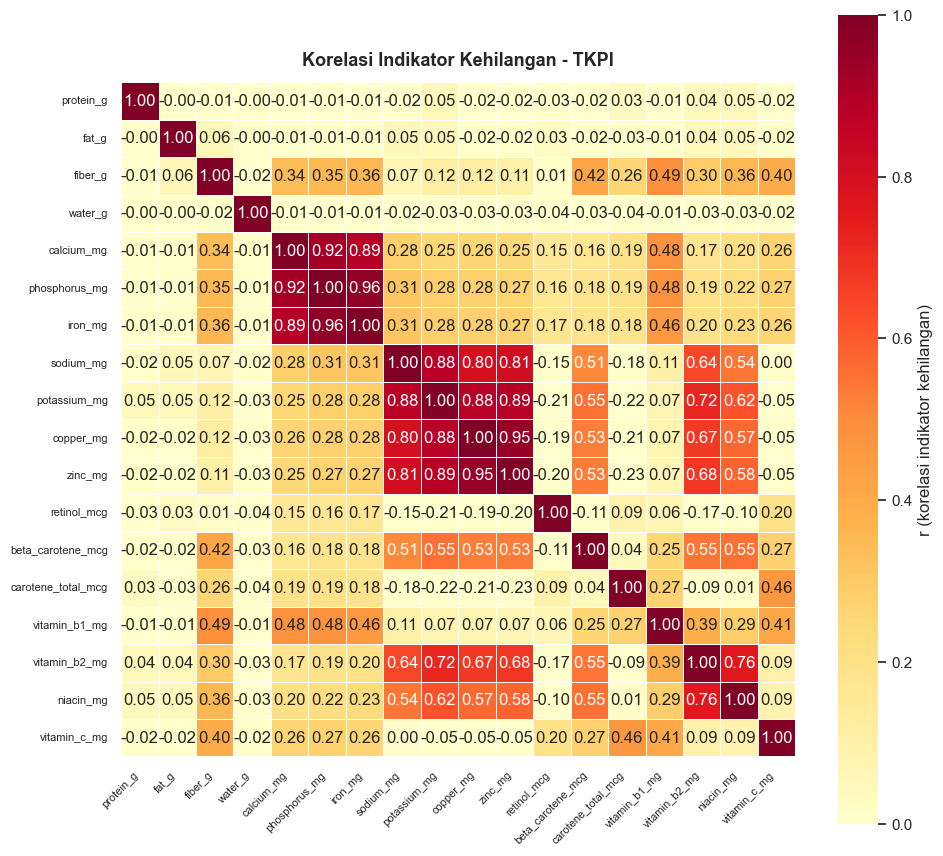


DATASET: MyFCD
Kelengkapan rerata (22 kolom nutrisi): 29.8%
  [info] Dikeluarkan (KOSONG TOTAL, 0% terisi): ['carotene_total_mcg', 'vitamin_a_mcg']

Ringkasan nilai r per kelompok:
                            label  n_pairs  mean_r  median_r  min_r  max_r
            MyFCD - semua nutrisi      190   0.365     0.334 -0.362    1.0
MyFCD - 15 mikronutrien (lengkap)       78   0.489     0.440  0.027    1.0
    MyFCD - mikronutrien: mineral       21   0.760     0.787  0.553    1.0
    MyFCD - mikronutrien: vitamin       15   0.444     0.140  0.027    1.0
         MyFCD - makronutrien (7)       21   0.828     0.897  0.669    1.0
      MyFCD - panel proksimat (6)       15   0.862     0.905  0.692    1.0
  [saved] missing_corr_MyFCD.csv
  [saved] ./output_missingness\heatmap_missing_MyFCD.png


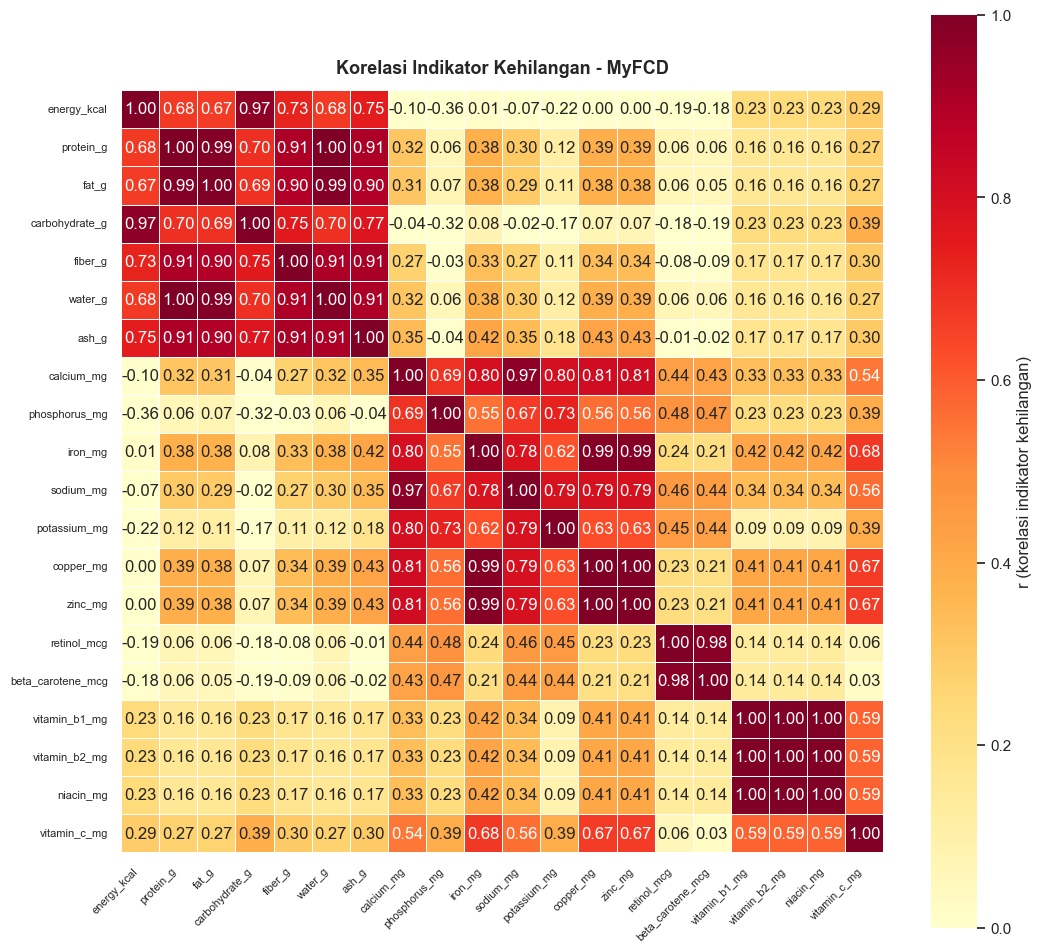


Nilai r pasangan mikronutrien TKPI:
  r(sodium_mg, potassium_mg) = 0.88
  r(sodium_mg, copper_mg) = 0.80
  r(copper_mg, zinc_mg) = 0.95
  r(vitamin_b1_mg, vitamin_b2_mg) = 0.39

Nilai r pasangan panel proksimat MyFCD:
  r(water_g, protein_g) = 1.00
  r(protein_g, fat_g) = 0.99
  r(fat_g, carbohydrate_g) = 0.69
  r(carbohydrate_g, ash_g) = 0.77


In [10]:
# ============================ 5. JALANKAN TKPI & MyFCD =======================
tkpi_corr,  tkpi_summary  = analyze_missingness(tkpi,  "TKPI")
myfcd_corr, myfcd_summary = analyze_missingness(myfcd, "MyFCD")
 
# ============================ 6. NILAI r PASANGAN SPESIFIK ===================
def show_pairs(corr, pairs, title):
    print(title)
    for a, b in pairs:
        if a in corr.columns and b in corr.columns:
            print(f"  r({a}, {b}) = {corr.loc[a, b]:.2f}")
        else:
            print(f"  r({a}, {b}) = - (salah satu kolom tak tersedia/konstan)")
 
show_pairs(tkpi_corr,
           [("sodium_mg","potassium_mg"), ("sodium_mg","copper_mg"),
            ("copper_mg","zinc_mg"), ("vitamin_b1_mg","vitamin_b2_mg")],
           "\nNilai r pasangan mikronutrien TKPI:")
 
show_pairs(myfcd_corr,
           [("water_g","protein_g"), ("protein_g","fat_g"),
            ("fat_g","carbohydrate_g"), ("carbohydrate_g","ash_g")],
           "\nNilai r pasangan panel proksimat MyFCD:")

In [5]:
# ============================ 7. PERBANDINGAN RINGKASAN ======================
comparison = pd.concat([tkpi_summary, myfcd_summary], ignore_index=True)
comparison.to_csv(os.path.join(OUTPUT_DIR, "ringkasan_r_perbandingan.csv"), index=False)
print("\nRingkasan nilai r - TKPI vs MyFCD:\n")
print(comparison.to_string(index=False))


Ringkasan nilai r - TKPI vs MyFCD:

                            label  n_pairs  mean_r  median_r  min_r  max_r
             TKPI - semua nutrisi      153   0.195     0.109 -0.229  0.963
 TKPI - 15 mikronutrien (lengkap)       91   0.290     0.255 -0.229  0.963
     TKPI - mikronutrien: mineral       21   0.537     0.311  0.247  0.963
     TKPI - mikronutrien: vitamin       21   0.206     0.199 -0.170  0.762
          TKPI - makronutrien (7)        6   0.004    -0.001 -0.020  0.060
       TKPI - panel proksimat (6)        6   0.004    -0.001 -0.020  0.060
            MyFCD - semua nutrisi      190   0.365     0.334 -0.362  1.000
MyFCD - 15 mikronutrien (lengkap)       78   0.489     0.440  0.027  1.000
    MyFCD - mikronutrien: mineral       21   0.760     0.787  0.553  1.000
    MyFCD - mikronutrien: vitamin       15   0.444     0.140  0.027  1.000
         MyFCD - makronutrien (7)       21   0.828     0.897  0.669  1.000
      MyFCD - panel proksimat (6)       15   0.862     0.905  0

[saved] ./output_missingness\heatmap_perbandingan_TKPI_MyFCD.png


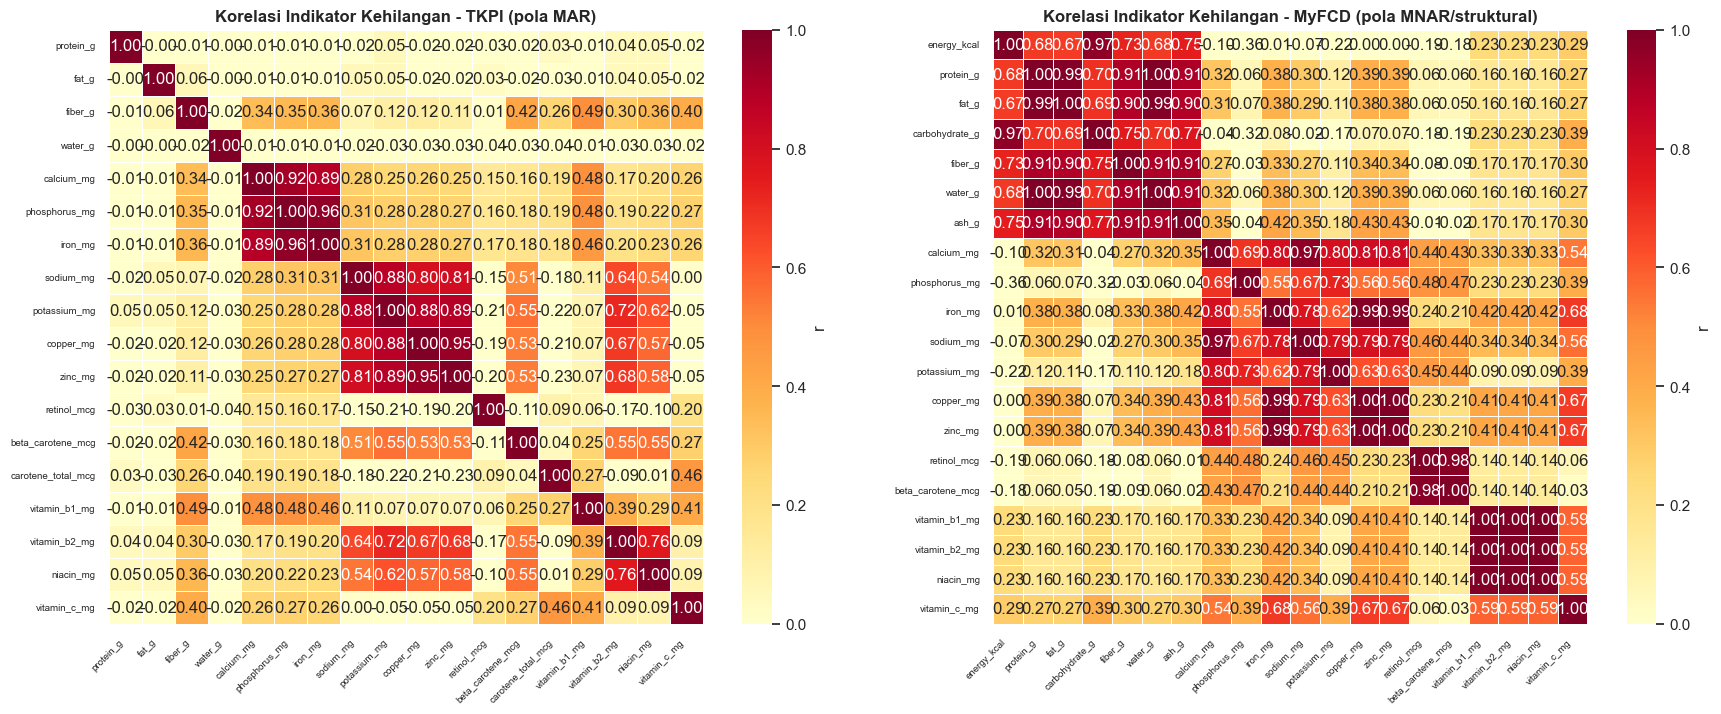

In [8]:
# ============================ 8. HEATMAP BERDAMPINGAN ========================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, corr, name in [(axes[0], tkpi_corr, "TKPI (pola MAR)"),
                       (axes[1], myfcd_corr, "MyFCD (pola MNAR/struktural)")]:
    n = corr.shape[0]
    sns.heatmap(corr, annot=(n <= 20), fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=1, square=True, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "r"}, ax=ax)
    ax.set_title(f"Korelasi Indikator Kehilangan - {name}", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=7); ax.tick_params(axis="y", labelsize=7)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
plt.tight_layout()
combined_path = os.path.join(OUTPUT_DIR, "heatmap_perbandingan_TKPI_MyFCD.png")
fig.savefig(combined_path, dpi=200, bbox_inches="tight")
print(f"[saved] {combined_path}")
plt.show()

In [ ]:
# ============================ 9. INTERPRETASI ================================
# - TKPI  : r tinggi terkonsentrasi di antara mikronutrien (blok) -> MAR
# - MyFCD : r ~1,0 pada panel proksimat & makronutrien (serempak) -> MNAR/struktural
# Uji Little's MCAR tidak membedakan MAR vs MNAR; analisis korelasi
# indikator kehilangan ini adalah bukti pelengkap penentu mekanisme.

In [8]:
for c in ['vitamin_a_mcg', 'carotene_total_mcg']:
    print(c, "→ jumlah tidak-kosong:", tkpi[c].notna().sum(), "dari", len(tkpi))

vitamin_a_mcg → jumlah tidak-kosong: 0 dari 1146
carotene_total_mcg → jumlah tidak-kosong: 607 dari 1146


In [9]:
# Tes untuk mengetahui penyebab carotene_total_mcg dikenali sebagai kolom kosong padahal memiliki jumlah yang tidak kosong
print("dtype:", tkpi['carotene_total_mcg'].dtype)
print("nunique indikator:", tkpi['carotene_total_mcg'].isna().astype(int).nunique())
print("contoh nilai:\n", tkpi['carotene_total_mcg'].dropna().head(10).tolist())
print("apakah carotene ada di daftar tkpi_cols?", 'carotene_total_mcg' in tkpi_cols)

dtype: float64
nunique indikator: 2
contoh nilai:
 [0.0, 0.0, 80.0, 0.0, 0.0, 0.0, 0.0, 261.0, 641.0, 385.0]
apakah carotene ada di daftar tkpi_cols? True


In [10]:
print("MyFCD carotene tidak-kosong:", myfcd['carotene_total_mcg'].notna().sum(), "dari", len(myfcd))
print("MyFCD vitamin_a tidak-kosong:", myfcd['vitamin_a_mcg'].notna().sum(), "dari", len(myfcd))

MyFCD carotene tidak-kosong: 0 dari 234
MyFCD vitamin_a tidak-kosong: 0 dari 234


In [9]:
# Availability matrix lengkap dengan label kelompok dan strategi imputasi
nutrient_cols = [c for c in ALL_NUTRIENTS if c in tkpi.columns and c in myfcd.columns]

avail = pd.DataFrame({
    'TKPI_terisi':  tkpi[nutrient_cols].notna().sum(),
    'TKPI_total':   len(tkpi),
    'MyFCD_terisi': myfcd[nutrient_cols].notna().sum(),
    'MyFCD_total':  len(myfcd),
})
avail['TKPI_pct']  = (avail['TKPI_terisi']  / avail['TKPI_total']  * 100).round(1)
avail['MyFCD_pct'] = (avail['MyFCD_terisi'] / avail['MyFCD_total'] * 100).round(1)

# Label kelompok nutrisi
def kelompok(c):
    if c in MICRONUTRIENTS_MINERAL: return 'Mineral'
    if c in MICRONUTRIENTS_VITAMIN: return 'Vitamin'
    return 'Makronutrien/Proksimat'
avail['kelompok'] = [kelompok(c) for c in avail.index]

# Strategi imputasi berdasarkan keterisian di kedua basis
def strategi(r):
    t, m = r['TKPI_pct'], r['MyFCD_pct']
    if t == 0 and m == 0:
        return 'Pinjam USDA (kosong di kedua basis)'
    if t == 0 or m == 0:
        return 'Cross-DB transfer / USDA'
    return 'Imputasi internal per basis'
avail['strategi_imputasi'] = avail.apply(strategi, axis=1)

# Urutkan berdasarkan keterisian TKPI (naik)
avail = avail.sort_values('TKPI_pct')

# Tampilkan kolom yang relevan
cols_tampil = ['kelompok', 'TKPI_terisi', 'TKPI_pct',
               'MyFCD_terisi', 'MyFCD_pct', 'strategi_imputasi']
print(avail[cols_tampil].to_string())

# (opsional) simpan ke CSV
avail.to_csv(f"{OUTPUT_DIR}/availability_matrix.csv")
print(f"\n[saved] {OUTPUT_DIR}/availability_matrix.csv")

                                  kelompok  TKPI_terisi  TKPI_pct  MyFCD_terisi  MyFCD_pct                    strategi_imputasi
vitamin_a_mcg                      Vitamin            0       0.0             0        0.0  Pinjam USDA (kosong di kedua basis)
retinol_mcg                        Vitamin          541      47.2            38       16.2          Imputasi internal per basis
carotene_total_mcg                 Vitamin          607      53.0             0        0.0             Cross-DB transfer / USDA
beta_carotene_mcg                  Vitamin          679      59.2            37       15.8          Imputasi internal per basis
copper_mg                          Mineral          795      69.4            49       20.9          Imputasi internal per basis
vitamin_b2_mg                      Vitamin          796      69.5            10        4.3          Imputasi internal per basis
zinc_mg                            Mineral          799      69.7            49       20.9          Impu